In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
bn22bc_dir="./BN22BC"
bn22bc_buckled_dir="./BN22BC_Buckled"
bn33bc_dir="./BN33BC"
bn44bc_dir="./BN44BC"

bn22nc_dir="./BN22NC"
bn33nc_dir="./BN33NC"
bn44nc_dir="./BN44NC"

"./BN44NC"

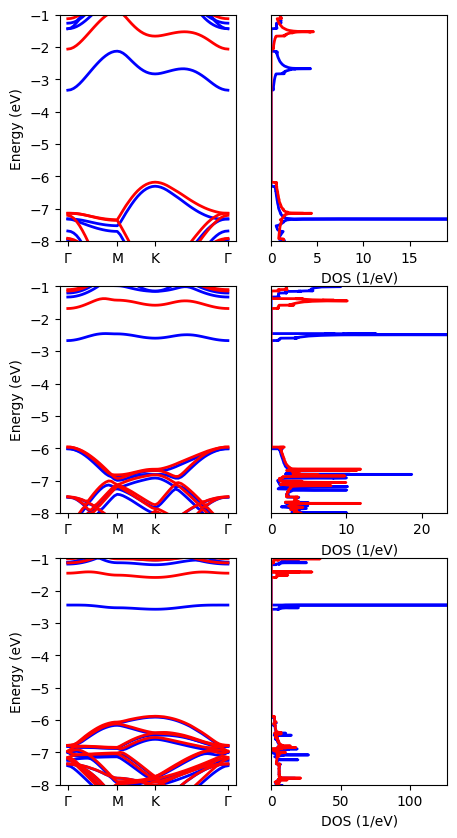

(-8.0, -1.0)

In [17]:
figure(figsize=(5, 10))
bandsoverlayedDOS2(bn22bc_dir*"/DOS/BN22BC.dosUp", bn22bc_dir*"/DOS/BN22BC.dosDn", bn22bc_dir*"/BN22BC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 1], dos_subplot=[3, 2, 2], dos_yticks=false)

bandsoverlayedDOS2(bn33bc_dir*"/DOS/BN33BC.dosUp", bn33bc_dir*"/DOS/BN33BC.dosDn", bn33bc_dir*"/BN33BC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 3], dos_subplot=[3, 2, 4], dos_yticks=false)

bandsoverlayedDOS2(bn44bc_dir*"/DOS/BN44BC.dosUp", bn44bc_dir*"/DOS/BN44BC.dosDn", bn44bc_dir*"/BN44BC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 5], dos_subplot=[3, 2, 6], dos_yticks=false)


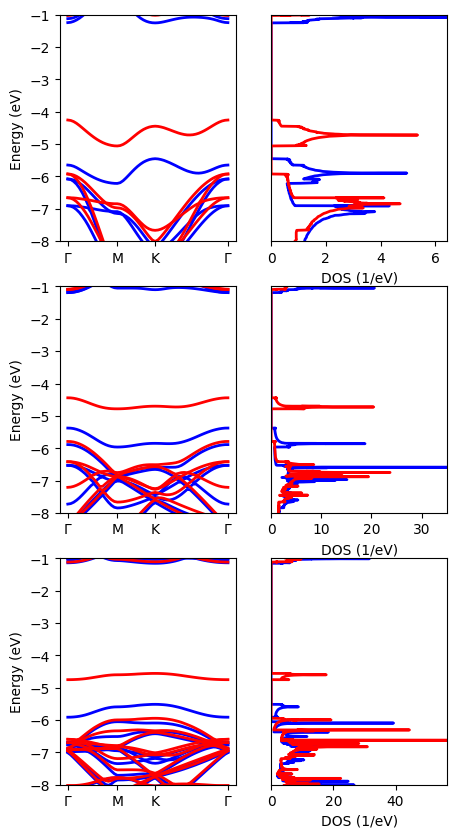

(-8.0, -1.0)

In [19]:
figure(figsize=(5, 10))
bandsoverlayedDOS2(bn22nc_dir*"/DOS/BN22NC.dosUp", bn22nc_dir*"/DOS/BN22NC.dosDn", bn22nc_dir*"/BN22NC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 1], dos_subplot=[3, 2, 2], dos_yticks=false)

bandsoverlayedDOS2(bn33nc_dir*"/DOS/BN33NC.dosUp", bn33nc_dir*"/DOS/BN33NC.dosDn", bn33nc_dir*"/BN33NC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 3], dos_subplot=[3, 2, 4], dos_yticks=false)

bandsoverlayedDOS2(bn44nc_dir*"/DOS/BN44NC.dosUp", bn44nc_dir*"/DOS/BN44NC.dosDn", bn44nc_dir*"/BN44NC.bands.eigenvals"
,(-8, -1), color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 5], dos_subplot=[3, 2, 6], dos_yticks=false)


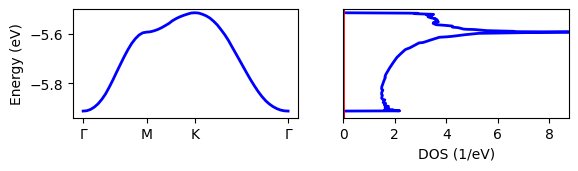

Total number of electrons in range: 0.9993739918898152


(-5.94, -5.5)

In [25]:
bandsoverlayedDOS2(bn44nc_dir*"/DOS/BN44NC.dosUp", bn44nc_dir*"/DOS/BN44NC.dosDn", bn44nc_dir*"/BN44NC.bands.eigenvals"
,(-5.94, -5.5), return_tot=true, color_up = "blue", color_dn="red", linewidth=2, band_subplot=[3, 2, 5], dos_subplot=[3, 2, 6], dos_yticks=false)


In [10]:
Energies22=zeros(100)
Magnetizations22=zeros(100)
for i in 1:100
    Magnetizations22[i] = get_mag("$bn22bc_dir/magnetization/BN22BC-$i.out")
    Energies22[i] = list_energy("$bn22bc_dir/magnetization/BN22BC-$i.out")
end

In [11]:
Energies33=zeros(100)
Magnetizations33=zeros(100)
for i in 1:100
    #println(i)
    try
    Magnetizations33[i] = get_mag("$bn33bc_dir/magnetization/BN33BC-$i.out")
    Energies33[i] = list_energy("$bn33bc_dir/magnetization/BN33BC-$i.out")
    catch
    end
end

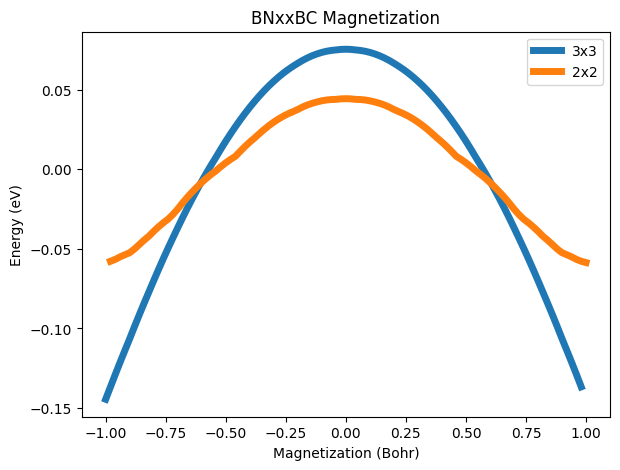

PyObject Text(0.5, 24.0, 'Magnetization (Bohr)')

In [17]:
figure(figsize=(15, 5))
subplot(1, 2, 1)
plot(Magnetizations33, Energies33 .-  mean(Energies33), linewidth=5, label="3x3")
title("BN33BC Magnetization")
ylabel("Energy (eV)")
title("BN33BC Magnetization")
xlabel("Magnetization (Bohr)")
#subplot(1, 2, 2)
plot(Magnetizations22, Energies22 .- mean(Energies22), linewidth=5, label="2x2")
ylabel("Energy (eV)")
title("BNxxBC Magnetization")
legend()
xlabel("Magnetization (Bohr)")

In [72]:
force_matrix, cell_map = phonon_force_matrix("$bn22bc_dir/phonon");
force_matrix_buckled, cell_map_buckled = phonon_force_matrix("$bn22bc_buckled_dir/phonon");

Number of phonon modes is: 24
If this is incorrect, something went wrong somewhere at some point.
Number of phonon modes is: 24
If this is incorrect, something went wrong somewhere at some point.


In [6]:
force_matrix, cell_map = phonon_force_matrix("$bn22nc_dir/phonon");
#force_matrix_buckled, cell_map_buckled = phonon_force_matrix("$bn22nc_buckled_dir/phonon");

Number of phonon modes is: 24
If this is incorrect, something went wrong somewhere at some point.


In [16]:
force_matrix, cell_map = phonon_force_matrix("$bn33nc_dir/phonon");
phonon_bands = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

Number of phonon modes is: 54
If this is incorrect, something went wrong somewhere at some point.


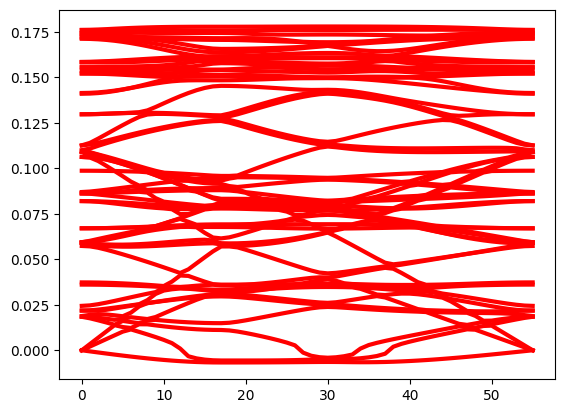

54-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f247def59a0>
 PyObject <matplotlib.lines.Line2D object at 0x7f247def5a00>
 PyObject <matplotlib.lines.Line2D object at 0x7f247def5ac0>
 PyObject <matplotlib.lines.Line2D object at 0x7f247def5b80>
 PyObject <matplotlib.lines.Line2D object at 0x7f247def5c40>
 PyObject <matplotlib.lines.Line2D object at 0x7f247def5d00>
 PyObject <matplotlib.lines.Line2D object at 0x7f247def5dc0>
 PyObject <matplotlib.lines.Line2D object at 0x7f247def5e80>
 PyObject <matplotlib.lines.Line2D object at 0x7f247def5f40>
 PyObject <matplotlib.lines.Line2D object at 0x7f247defe040>
 PyObject <matplotlib.lines.Line2D object at 0x7f247defe100>
 PyObject <matplotlib.lines.Line2D object at 0x7f247defe1c0>
 PyObject <matplotlib.lines.Line2D object at 0x7f247defe280>
 ⋮
 PyObject <matplotlib.lines.Line2D object at 0x7f247de84940>
 PyObject <matplotlib.lines.Line2D object at 0x7f247de84a00>
 PyObject <matplotlib.lines.Line2D object at 0x7f247d

In [17]:
plot(phonon_bands, linewidth=3, color="red")


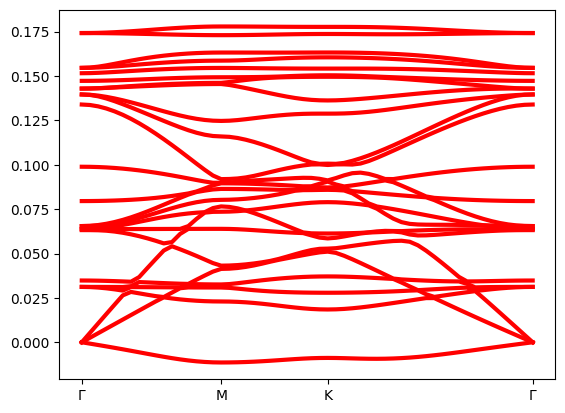

(PyObject[PyObject <matplotlib.axis.XTick object at 0x7f24e425baf0>, PyObject <matplotlib.axis.XTick object at 0x7f24e425bac0>, PyObject <matplotlib.axis.XTick object at 0x7f24e4255640>, PyObject <matplotlib.axis.XTick object at 0x7f24e428ed00>], PyObject[PyObject Text(0, 0, 'Γ'), PyObject Text(17, 0, 'M'), PyObject Text(30, 0, 'K'), PyObject Text(55, 0, 'Γ')])

In [9]:
plot(phonon_bands, linewidth=3, color="red")
label_plots()

In [5]:
phonon_bands = phonon_dispersionpath(force_matrix, cell_map, kpointsfile="bandstruct.kpoints", return_negative=true);

In [73]:
phonon_bands_buckled = phonon_dispersionpath(force_matrix_buckled, cell_map_buckled, kpointsfile="bandstruct.kpoints", return_negative=true);

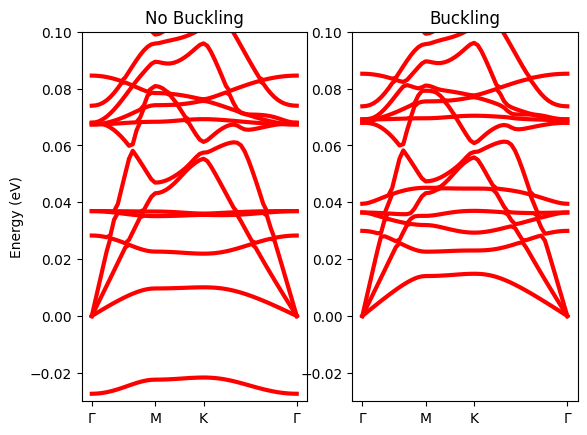

(-0.03, 0.1)

In [78]:
subplot(1, 2, 1)
plot(phonon_bands, linewidth=3, color="red")
label_plots()
ylabel("Energy (eV)")
title("No Buckling")
ylim(-0.03, 0.1)
subplot(1, 2, 2)
plot(phonon_bands_buckled, linewidth=3, color="red")
label_plots()
title("Buckling")
ylim(-0.03, 0.1)

In [43]:
[p[1] for p in phonon_dispersion.(Ref(force_matrix), Ref(cell_map), [q  for q in [k ./ 100 *i for i in 1:100]] , return_negative=true)*eV]

100-element Vector{Float64}:
 -0.0010052070642324227
 -0.0010052070642186113
 -0.0010052070641955984
 -0.0010052070641633857
 -0.0010052070641219622
 -0.0010052070640713358
 -0.0010052070640114948
 -0.0010052070639424602
 -0.0010052070638642135
 -0.0010052070637767622
 -0.0010052070636801026
 -0.0010052070635742445
 -0.0010052070634591758
  ⋮
 -0.001005207027779312
 -0.001005207026955433
 -0.001005207026122351
 -0.0010052070252800633
 -0.0010052070244285663
 -0.0010052070235678767
 -0.0010052070226979671
 -0.0010052070218188615
 -0.001005207020930538
 -0.0010052070200330244
 -0.0010052070191262964
 -0.0010052070182103752

In [55]:
phonon_dispersion(force_matrix, cell_map, [0, 0, 0], return_negative=true)

24-element Vector{Float64}:
 -0.027353091507779658
 -2.7548140271950296e-9
  1.192205469443938e-9
  2.840727159445403e-9
  0.02830012431393632
  0.03689346577838627
  0.036893465778386376
  0.06736950578652433
  0.06736950578652438
  0.06796372752641981
  0.06796372752641998
  0.07396211213039897
  0.08454737262219467
  0.1342849153744948
  0.1456788903194319
  0.14567889031943193
  0.15102265364038214
  0.15530589619537563
  0.15530589619537571
  0.16317930900675218
  0.1631793090067522
  0.16339725915708697
  0.1716007337040448
  0.17160073370404494

In [80]:
abs.(phonon_dispersionmodes(force_matrix_buckled, cell_map_buckled, [0, 0, 0])[2][:, 7])

24-element Vector{Float64}:
 0.00015504930216639438
 0.002802882224382881
 0.9255270925440272
 0.0003495030103355054
 0.004836314109344728
 0.1379024196635248
 0.0031672942674610643
 0.002270892646174503
 0.15038334747894314
 0.00014260674065921732
 0.0012529765033123246
 0.009449834139348386
 0.003552012945569296
 0.0024287089574255606
 0.15143030238869845
 0.0009332577006218294
 0.0003585842907014526
 0.15953067723244793
 0.00014934703490241275
 0.0008190463958557383
 0.16442194736219276
 0.001123795426297939
 0.0005061348118337387
 0.16184073759367903

In [81]:
zero_es = JJDFTX.dos_properties(bn33nc_dir*"/DOS/BN33NC.dosDn")

15-element Vector{Float64}:
 -23.425537092407126
 -22.91780992647554
 -22.895658204012634
 -21.720957212058305
 -20.651416536770675
 -20.64034548052658
 -20.0466498136617
 -16.39051085556528
 -16.296382476989198
 -14.597152110026345
  -5.790171196749301
  -4.781500779872232
  -4.440979981722387
  -1.0931504346717151
   5.366031539015967

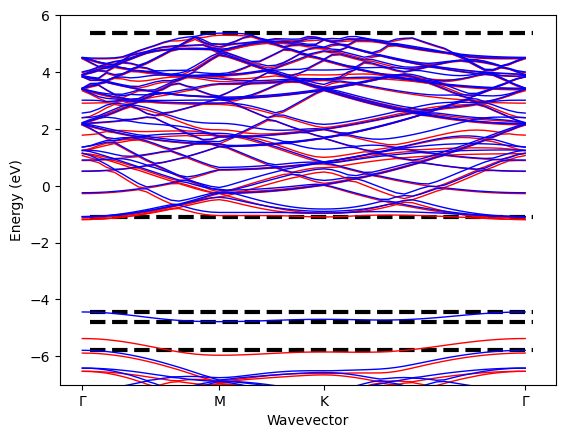

PyObject <matplotlib.collections.LineCollection object at 0x7f247c512850>

In [90]:
plot_bands("$bn33nc_dir/BN33NC.bands.eigenvals", spin=2, to_greek=true, color_dn = "blue", color_up = "red", linewidth=1)
ylim(-7, 6)
hlines(zero_es, 1, 56, linewidth=3, linestyle="dashed", color="black")

In [4]:
readdir(bn22bc_dir)

253-element Vector{String}:
 ".ipynb_checkpoints"
 "Analyze.ipynb"
 "BN22BC.bands.eigenvals"
 "BN22BC.bands.in"
 "BN22BC.bands.out"
 "BN22BC.eigenvals"
 "BN22BC.fillings"
 "BN22BC.in"
 "BN22BC.ionpos"
 "BN22BC.lattice"
 "BN22BC.n_dn"
 "BN22BC.n_up"
 "BN22BC.out"
 ⋮
 "wannier.mlwfCellWeightsUp"
 "wannier.mlwfHDn"
 "wannier.mlwfHUp"
 "wannier.mlwfM0Dn"
 "wannier.mlwfM0Up"
 "wannier.mlwfUDn"
 "wannier.mlwfUUp"
 "wannier.out"
 "wannierDn.map.txt"
 "wannierDn.txt"
 "wannierUp.map.txt"
 "wannierUp.txt"

In [26]:
im_ee = np.reshape(np.fromfile(bn22bc_dir*"/GW/BN22BC.ImSigma_ee"), (6, 32))[4:6, :]

3×32 Matrix{Float64}:
 0.104762  0.0959889  0.0995125  …  0.00955682  0.00287885  0.00469759
 0.107673  0.113022   0.103191      0.0107882   0.00955608  0.00411018
 0.121241  0.114684   0.120565      0.00233791  0.00684468  0.00785604

In [32]:
im_ee[:, 32]

3-element Vector{Float64}:
 0.004697591894203059
 0.00411017717743335
 0.00785604151315086